In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
#    for filename in filenames:
#        print(os.path.join(dirname, filename))

import cv2
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import random
from torchvision.transforms import v2
import random
import torch
# Set seeds for reproducibility
# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
import torch


In [5]:
file_img = '/kaggle/input/platesv2/plates.zip'
file_out = '/kaggle/working'

import zipfile
# Open the ZIP file
with zipfile.ZipFile(file_img, 'r') as zip_ref:
    # Extract all contents to a directory
    zip_ref.extractall(file_out)
print("ZIP file extracted successfully!")

ZIP file extracted successfully!


In [6]:
train_file = '/kaggle/working/plates/train'
test_file = '/kaggle/working/plates/test'


clean_file = '/kaggle/working/plates/train/cleaned'
dirty_file = '/kaggle/working/plates/train/dirty'

test_file = '/kaggle/working/plates/test'
train_folder = [clean_file,dirty_file,test_file]

full_img = []

for each in train_folder:
    tmp_img = []
    for dirname, _, filenames in os.walk(each):
        for filename in filenames:
            #print(filename)
            #print(os.path.join(dirname, filename))
            if filename != '.DS_Store':
                tmp_img.append(os.path.join(dirname, filename))
        full_img.append(tmp_img)

train_cleaned_names = full_img[0]
train_dirty_names = full_img[1]
test_img_name = full_img[2]


In [7]:
print('the images as cleaned in the train are: ',len(train_cleaned_names))
print('the images as dirty in the train are: ',len(train_dirty_names))
print('the images the test are: ',len(test_img_name))


print('image size in train:',cv2.imread(train_cleaned_names[0]).shape)
print('image size in train:',cv2.imread(train_cleaned_names[2]).shape)


the images as cleaned in the train are:  20
the images as dirty in the train are:  20
the images the test are:  744
image size in train: (256, 342, 3)
image size in train: (341, 256, 3)


In [8]:
train = train_cleaned_names + train_dirty_names
print(len(train))
x = train
y = [1]*len(train_cleaned_names)+ [0]*len(train_dirty_names)

40


In [9]:
import os
from sklearn.model_selection import train_test_split

x = train_cleaned_names + train_dirty_names
y = [1]*len(train_cleaned_names) + [0]*len(train_dirty_names)

x_train,x_val,y_train,y_val = train_test_split(x,y,test_size = 0.2,random_state = 42)

print(len(x_train))
print(len(x_val))
print(len(y_train))
print(len(y_val))
test = test_img_name
print(len(test))

32
8
32
8
744


# Check YOLO if the plates are detected

In [10]:
pip install ultralytics opencv-python numpy torch torchvision torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 922.2/922.2 kB 34.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [11]:
from ultralytics import YOLO

# Load the YOLOv8 model
model = YOLO("yolov8n.pt",verbose = False)  # Load pre-trained weights
print(model.names)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 6.25M/6.25M [00:00<00:00, 311MB/s]

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

**what i expect from yolo is to detect bowl together with any other detections which may not be very important for me.**

In [12]:
from contextlib import redirect_stdout

#test with random 20 images
for i in range(20):
    img_path = random.choice(test)
    #image = cv2.imread(img_path)
    print(f'{i+1}th image: {img_path}')
    results = model(img_path)

    for result in results:
        if len(result.boxes) == 0:
            print('NO DETECTION!')
        else:
            for box in result.boxes:
                class_id = int(box.cls)  # Get class ID
                class_name = model.names[class_id]  # Get class name from the model
                print(f"DETECTED: {class_name}")
    print('---------------------------------------------------------')

1th image: /kaggle/working/plates/test/0613.jpg

image 1/1 /kaggle/working/plates/test/0613.jpg: 480x640 1 bowl, 1 orange, 1 dining table, 188.7ms
Speed: 10.9ms preprocess, 188.7ms inference, 15.0ms postprocess per image at shape (1, 3, 480, 640)
DETECTED: dining table
DETECTED: orange
DETECTED: bowl
---------------------------------------------------------
2th image: /kaggle/working/plates/test/0073.jpg

image 1/1 /kaggle/working/plates/test/0073.jpg: 480x640 1 toilet, 88.9ms
Speed: 1.3ms preprocess, 88.9ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)
DETECTED: toilet
---------------------------------------------------------
3th image: /kaggle/working/plates/test/0467.jpg

image 1/1 /kaggle/working/plates/test/0467.jpg: 480x640 1 toilet, 92.6ms
Speed: 1.6ms preprocess, 92.6ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)
DETECTED: toilet
---------------------------------------------------------
4th image: /kaggle/working/plates/test/0588.jpg

ima

**Takeaways**

> Yolo cannot detect the plates very well. Lets do this with manuel tunning by using cv2.GrabCut

## Background Remover with GrabCut:

In [13]:
def remove_background(image):
    mask = np.zeros(image.shape[:2], np.uint8)
    bg_model = np.zeros((1, 65), np.float64)
    fg_model = np.zeros((1, 65), np.float64)
    
    rect = (20, 20, image.shape[1] - 40, image.shape[0] - 40)  # Define a rough bounding box
    cv2.grabCut(image, mask, rect, bg_model, fg_model, 5, cv2.GC_INIT_WITH_RECT)
    
    mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype("uint8")
    foreground = image * mask2[:, :, np.newaxis]
    foreground = cv2.resize(foreground,(224,224))
    return foreground

0 /kaggle/working/plates/train/cleaned/0016.jpg
1 /kaggle/working/plates/train/dirty/0003.jpg
0 /kaggle/working/plates/train/dirty/0009.jpg
1 /kaggle/working/plates/train/cleaned/0003.jpg
0 /kaggle/working/plates/train/dirty/0002.jpg
1 /kaggle/working/plates/train/dirty/0013.jpg
0 /kaggle/working/plates/train/cleaned/0013.jpg
1 /kaggle/working/plates/train/cleaned/0014.jpg
0 /kaggle/working/plates/train/cleaned/0015.jpg
1 /kaggle/working/plates/train/dirty/0001.jpg


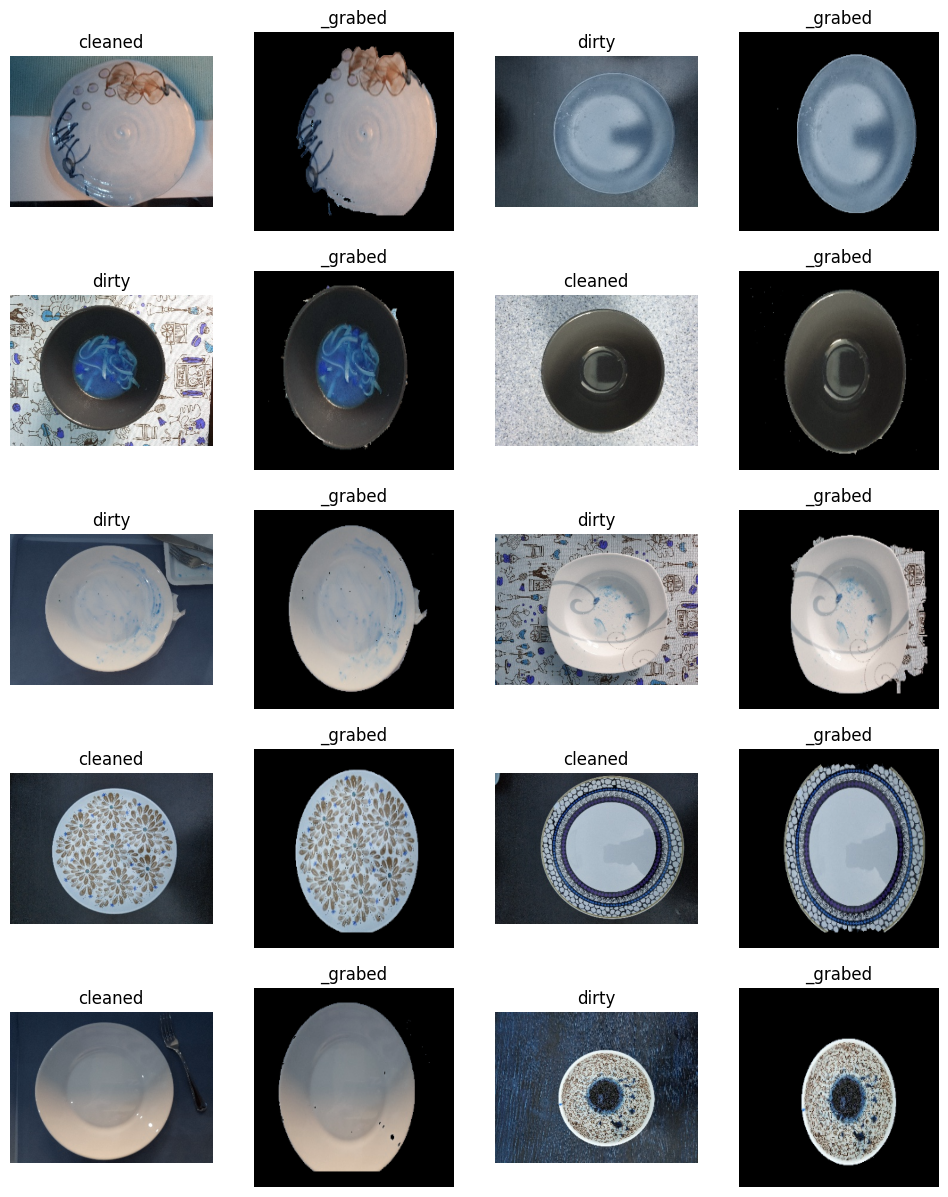

In [14]:
fig,ax = plt.subplots(5,4,figsize = (12,15))
for i in range(5):
    image1 = random.choice(x)
    image2 = random.choice(x)

    for j,img in enumerate([image1,image2]):
        print(j,img)
        imaj = cv2.imread(img)
        #imaj = cv2.resize(imaj,(224,224))
    
        ax[i][j*2].imshow(imaj)
        ax[i][j*2].axis('off')
        ax[i][j*2].set_title(img.split('/')[5])

        ax[i][j*2+1].imshow(remove_background(imaj))
        ax[i][j*2+1].axis('off')
        ax[i][j*2+1].set_title('_grabed')    

plt.show()

In [15]:
#os.path.basename('/kaggle/working/plates/train/dirty/0006.jpg')
a = '/kaggle/working/plates/train/dirty/0006.jpg'
print(a.split('/')[5])

dirty


It seems nicer :)

Dont forget that resnet expects --->(C, H, W)

## Dataset for Dataloader

In [16]:
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader

class PlateDataset(Dataset):
    def __init__ (self,link,label=None,transform = None):
        self.link = link
        self.label = label
        self.transform = transform

    def __len__(self):
        return len(self.link)

    def __getitem__(self,idx):
        each_link = self.link[idx]
        #each_label = self.label[idx] if self.label is not None else None
        imaj = cv2.imread(each_link)
        imaj = cv2.resize(imaj,(224,224))
        color_imaj = cv2.cvtColor(imaj,cv2.COLOR_BGR2RGB)
        wo_bg_imaj = remove_background(color_imaj) #without background


        if self.transform: #Apply transform
            #print(tensor.shape) #120,120,3
            tensor = torch.from_numpy(wo_bg_imaj).permute(2, 0, 1).float()/255 #normalize it here
            #If the input tensor is already torch.float32, scale=True in compose doesn’t perform scaling because it assumes the data is already scaled
            transformed = self.transform(tensor)
            tensor = transformed
            
        if self.label is not None:
            each_label = self.label[idx]
            return tensor, torch.tensor(each_label)
        else:
            #print(type(tensor))
            return tensor
            

In [17]:
'''
class MeanSTDCalculator():
    def __init__(self,inputs):
        self.input = inputs
       

    def calculation(self):
        avg_mean = [] #[b,g,r]
        avg_std = []  #[b,g,r]
        
        num_img = len(self.input)

        m_b, s_b = 0.0, 0.0
        m_g, s_g = 0.0, 0.0
        m_r, s_r = 0.0, 0.0


        for each in self.input:
            #print(each)
            image = cv2.imread(each)
            image = cv2.resize(image,(224,224))
            image = image.astype(np.float32)/255
            b,g,r = cv2.split(image)

            # Accumulate sums for mean
            m_b += np.mean(b)
            m_g += np.mean(g)
            m_r += np.mean(r)
    
            # Accumulate sums for std
            s_b += np.std(b)
            s_g += np.std(g)
            s_r += np.std(r)

        # Final mean and std values across all images
        m_b /= num_img
        m_g /= num_img
        m_r /= num_img

        s_b /= num_img
        s_g /= num_img
        s_r /= num_img


        return np.round([m_b, m_g, m_r], 2).tolist(), np.round([s_b, s_g, s_r], 2).tolist()

std_mean = MeanSTDCalculator(x)
train_mean , train_std = std_mean.calculation()

std_mean = MeanSTDCalculator(test)
test_mean,test_std = std_mean.calculation()
'''

'\nclass MeanSTDCalculator():\n    def __init__(self,inputs):\n        self.input = inputs\n       \n\n    def calculation(self):\n        avg_mean = [] #[b,g,r]\n        avg_std = []  #[b,g,r]\n        \n        num_img = len(self.input)\n\n        m_b, s_b = 0.0, 0.0\n        m_g, s_g = 0.0, 0.0\n        m_r, s_r = 0.0, 0.0\n\n\n        for each in self.input:\n            #print(each)\n            image = cv2.imread(each)\n            image = cv2.resize(image,(224,224))\n            image = image.astype(np.float32)/255\n            b,g,r = cv2.split(image)\n\n            # Accumulate sums for mean\n            m_b += np.mean(b)\n            m_g += np.mean(g)\n            m_r += np.mean(r)\n    \n            # Accumulate sums for std\n            s_b += np.std(b)\n            s_g += np.std(g)\n            s_r += np.std(r)\n\n        # Final mean and std values across all images\n        m_b /= num_img\n        m_g /= num_img\n        m_r /= num_img\n\n        s_b /= num_img\n        

In [18]:

'''
If it is below, train_transforms give the same result in each epoch. so i need to make it call in the next code line

train_transforms = random.choice([
    v2.Compose([
        v2.CenterCrop((180, 180)),  # More balanced than (20,200)
        v2.Resize((224, 224), antialias=True),
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomRotation(degrees=(-15, 15), fill=0),  # Less extreme rotation
        v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        v2.Normalize(mean=train_mean, std=train_std)
    ]),
    v2.Compose([
        v2.RandomResizedCrop(size=(224, 224), scale=(0.85, 1.0), antialias=True),
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomVerticalFlip(p=0.3),
        v2.RandomGrayscale(p=0.2),
        v2.Normalize(mean=train_mean, std=train_std)
    ]),
    v2.Compose([
        v2.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), antialias=True),
        v2.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.95, 1.05), shear=5),
        v2.RandomPerspective(distortion_scale=0.2, p=0.5),
        v2.Normalize(mean=train_mean, std=train_std)
    ]),
    v2.Compose([
        v2.CenterCrop((180, 180)),  # Keeping center-focused augmentation
        v2.Resize((224, 224), antialias=True),
        v2.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
        v2.Normalize(mean=train_mean, std=train_std)
    ]),
    v2.Compose([
        v2.RandomResizedCrop(size=(224, 224), scale=(0.85, 1.0), antialias=True),
        v2.RandomErasing(p=0.3, scale=(0.05, 0.15), ratio=(0.5, 2.0), value=train_mean),  # More natural erasing
        v2.Normalize(mean=train_mean, std=train_std)
    ]),

    v2.Compose([
        v2.RandomResizedCrop(size=(224, 224), scale=(0.75, 1.0), antialias=True),
        v2.RandomHorizontalFlip(p=0.7),
        v2.RandomVerticalFlip(p=0.7),
        v2.RandomRotation(degrees=(-45, 45), fill=0),
        v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        v2.RandomAffine(degrees=0, translate=(0.2, 0.2), scale=(0.8, 1.2), shear=15),
        v2.RandomPerspective(distortion_scale=0.15, p=0.5),
        v2.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
        v2.Normalize(mean=train_mean, std=train_std)
    ])
])


val_transforms = v2.Compose([
    v2.CenterCrop((180, 180)),  # Fixed crop for consistency
    v2.Resize((224, 224)),
    v2.RandomHorizontalFlip(p=0.5),  
    v2.Normalize(mean=train_mean, std=train_mean)
])

test_transforms = v2.Compose([
    v2.CenterCrop((180, 180)),  # Crop around plate area
    v2.Resize((224, 224)),  # Zoom in to make it more visible
    v2.Normalize(mean=train_mean, std=train_mean)  # Keep normalization    
])
'''

'\nIf it is below, train_transforms give the same result in each epoch. so i need to make it call in the next code line\n\ntrain_transforms = random.choice([\n    v2.Compose([\n        v2.CenterCrop((180, 180)),  # More balanced than (20,200)\n        v2.Resize((224, 224), antialias=True),\n        v2.RandomHorizontalFlip(p=0.5),\n        v2.RandomRotation(degrees=(-15, 15), fill=0),  # Less extreme rotation\n        v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),\n        v2.Normalize(mean=train_mean, std=train_std)\n    ]),\n    v2.Compose([\n        v2.RandomResizedCrop(size=(224, 224), scale=(0.85, 1.0), antialias=True),\n        v2.RandomHorizontalFlip(p=0.5),\n        v2.RandomVerticalFlip(p=0.3),\n        v2.RandomGrayscale(p=0.2),\n        v2.Normalize(mean=train_mean, std=train_std)\n    ]),\n    v2.Compose([\n        v2.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), antialias=True),\n        v2.RandomAffine(degrees=10, translate=(0.05, 0.05), sca

In [59]:
### In order to make random transform different at each call:
train_mean, train_std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

def train_random_transform(): 
    return  random.choice([
            
    v2.Compose([
    v2.CenterCrop((200, 200)),  # Fixed crop for consistency
    v2.Resize((224, 224), antialias=True),
    v2.RandomHorizontalFlip(p=0.3),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    v2.Normalize(mean=train_mean, std=train_std)]),

    v2.Compose([
    v2.CenterCrop((180, 180)),  # Fixed crop for consistency
    v2.Resize((224, 224)),
    v2.Normalize(mean=train_mean, std=train_std)]),    
        
    v2.Compose([
    v2.CenterCrop((160, 160)),  # Fixed crop for consistency
    v2.Resize((224, 224)),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    v2.Normalize(mean=train_mean, std=train_std)]),
        
    v2.Compose([
    v2.CenterCrop((140, 140)),  # Fixed crop for consistency
    v2.Resize((224, 224)),
    v2.RandomHorizontalFlip(p=0.5),  
    v2.Normalize(mean=train_mean, std=train_std)]),
    ])


def val_random_transform(): 
    return  random.choice([
    v2.Compose([
    v2.CenterCrop((180, 180)),  # Fixed crop for consistency
    v2.Resize((224, 224)),
    v2.Normalize(mean=train_mean, std=train_std)]),

    v2.Compose([
    v2.CenterCrop((160, 160)),  # Fixed crop for consistency
    v2.Resize((224, 224)),
    v2.Normalize(mean=train_mean, std=train_std)])
     ])

test_transforms = v2.Compose([
    v2.CenterCrop((170, 170)),  # Crop around plate area
    v2.Resize((224, 224)),  # Zoom in to make it more visible
    v2.Normalize(mean=train_mean, std=train_std)  # Keep normalization    
])

In [20]:
random.seed(None)

#control
for i in range(10):
    print(train_random_transform())

Compose(
      CenterCrop(size=(160, 160))
      Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      RandomHorizontalFlip(p=0.5)
      ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)
Compose(
      CenterCrop(size=(130, 130))
      Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)
Compose(
      CenterCrop(size=(120, 120))
      Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)

In [21]:
stopper!

SyntaxError: invalid syntax (<ipython-input-21-0fb455405490>, line 1)

## Lets see the train and val data 

In [22]:
train_dataset = PlateDataset(x_train,y_train,transform =train_random_transform()) #random.choice(train_transforms)
train_dataloader = DataLoader(train_dataset, batch_size= 8,shuffle = True,drop_last=False,num_workers=torch.cuda.device_count()) # to get the left overs

val_dataset = PlateDataset(x_val,y_val,transform = val_transforms)
val_dataloader = DataLoader(val_dataset, batch_size= 8,drop_last=False,num_workers=torch.cuda.device_count())

#lets see if they are sending different transforms at each transform:

selected transform:  Compose(
      CenterCrop(size=(120, 120))
      Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)


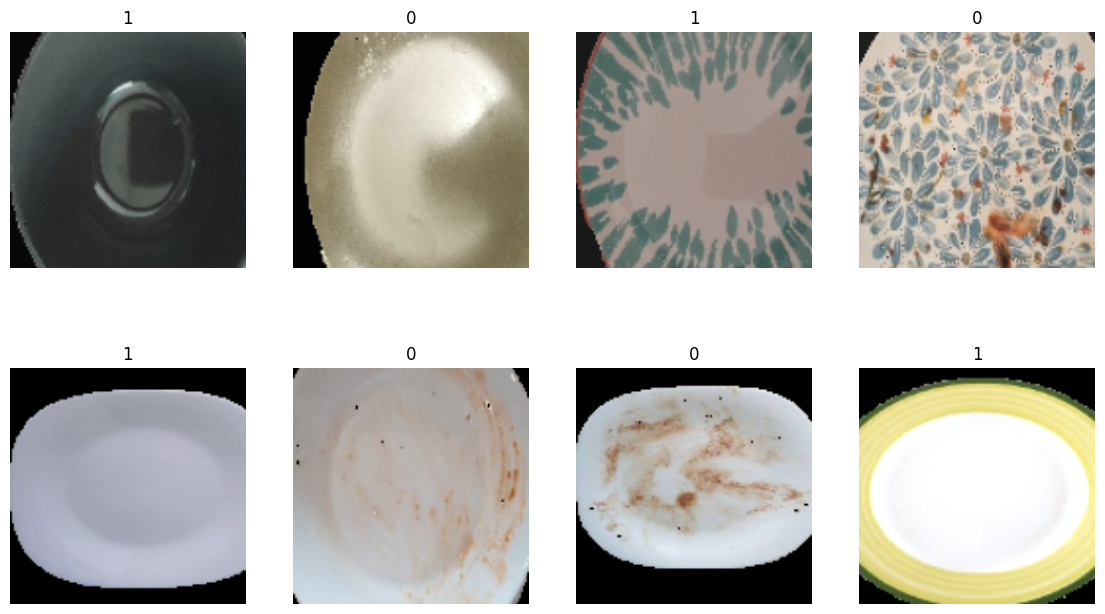

In [24]:
train_trans =  train_random_transform()
print('selected transform: ',train_trans)
train_dataset = PlateDataset(x_train,y_train,transform =train_trans) #random.choice(train_transforms)
train_dataloader = DataLoader(train_dataset, batch_size= 8,shuffle = True,drop_last=False,num_workers=torch.cuda.device_count()) # to get the left overs

for img,lab in iter(train_dataloader):
    fig,ax = plt.subplots(2,4,figsize = (14,8))
    for i in range(2):
        for j in range(4):
            indx = i*4+j
            label = lab[indx].item() 
            #print(img[indx].shape) #torch.Size([3, 224, 224])
            img_permute = img[indx].permute(1,2,0)
            #print(img_permute.shape) #torch.Size([224, 224, 3])
            img_numpy = img_permute.numpy()
            image = img_numpy*train_std + train_mean # denormalization
            ax[i][j].imshow(image)
            ax[i][j].set_title(str(label))
            ax[i][j].axis('off')
    break
            
plt.show()
    

selected transform:  Compose(
      CenterCrop(size=(160, 160))
      Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      RandomHorizontalFlip(p=0.5)
      ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)


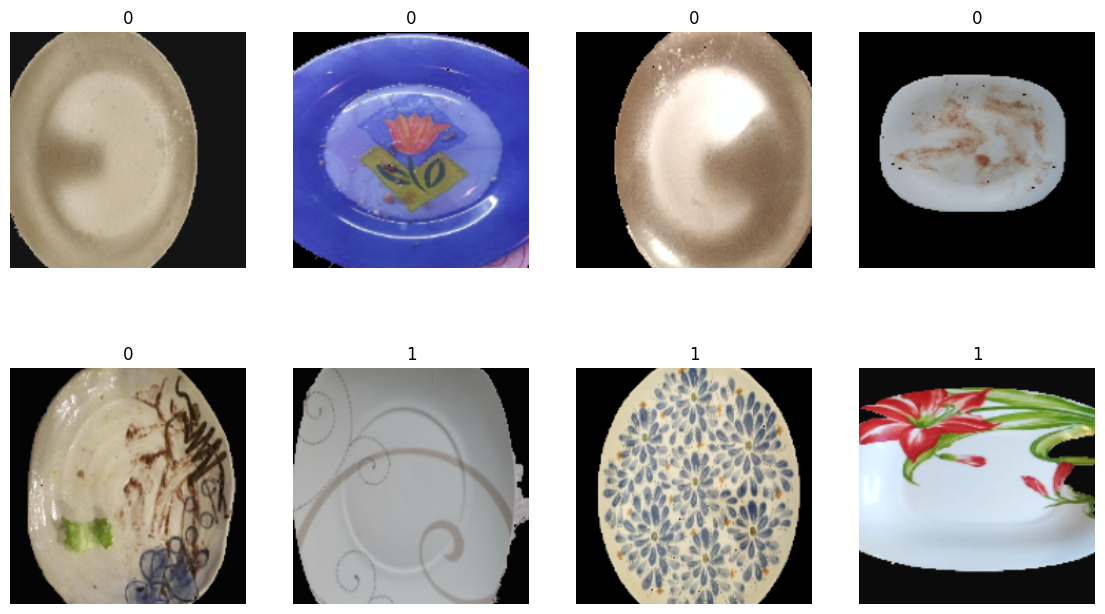

In [25]:
train_trans = train_random_transform()
print('selected transform: ',train_trans)
train_dataset = PlateDataset(x_train,y_train,transform =train_trans) #random.choice(train_transforms)
train_dataloader = DataLoader(train_dataset, batch_size= 8,shuffle = True,drop_last=False,num_workers=torch.cuda.device_count()) # to get the left overs

for img,lab in iter(train_dataloader):
    fig,ax = plt.subplots(2,4,figsize = (14,8))
    for i in range(2):
        for j in range(4):
            indx = i*4+j
            label = lab[indx].item() 
            #print(img[indx].shape) #torch.Size([3, 224, 224])
            img_permute = img[indx].permute(1,2,0)
            #print(img_permute.shape) #torch.Size([224, 224, 3])
            img_numpy = img_permute.numpy()
            image = img_numpy*train_std + train_mean # denormalization
            ax[i][j].imshow(image)
            ax[i][j].set_title(str(label))
            ax[i][j].axis('off')
    break
            
plt.show()
    

selected transform:  Compose(
      CenterCrop(size=(140, 140))
      Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)


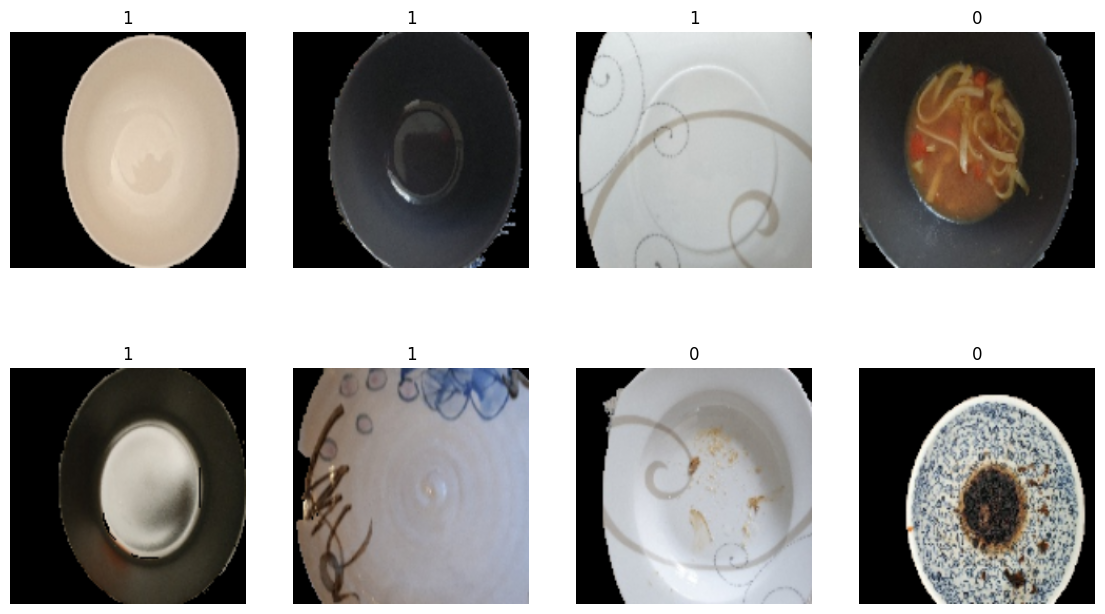

In [26]:
val_transforms = v2.Compose([
    v2.CenterCrop((140, 140)),  # Fixed crop for consistency
    v2.Resize((224, 224)),
    v2.Normalize(mean=train_mean, std=train_std)
])

print('selected transform: ',val_transforms)
val_dataset = PlateDataset(x_val,y_val,transform = val_transforms)
val_dataloader = DataLoader(val_dataset, batch_size= 8,drop_last=False,num_workers=torch.cuda.device_count())

for img,lab in iter(val_dataloader):
    fig,ax = plt.subplots(2,4,figsize = (14,8))
    for i in range(2):
        for j in range(4):
            indx = i*4+j
            label = lab[indx].item() 
            #print(img[indx].shape) #torch.Size([3, 224, 224])
            img_permute = img[indx].permute(1,2,0)
            #print(img_permute.shape) #torch.Size([224, 224, 3])
            img_numpy = img_permute.numpy()
            image = img_numpy*train_std + train_mean # denormalization
            ax[i][j].imshow(image)
            ax[i][j].set_title(str(label))
            ax[i][j].axis('off')
    break
            
plt.show()
    

selected transform:  Compose(
      CenterCrop(size=(140, 140))
      Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)


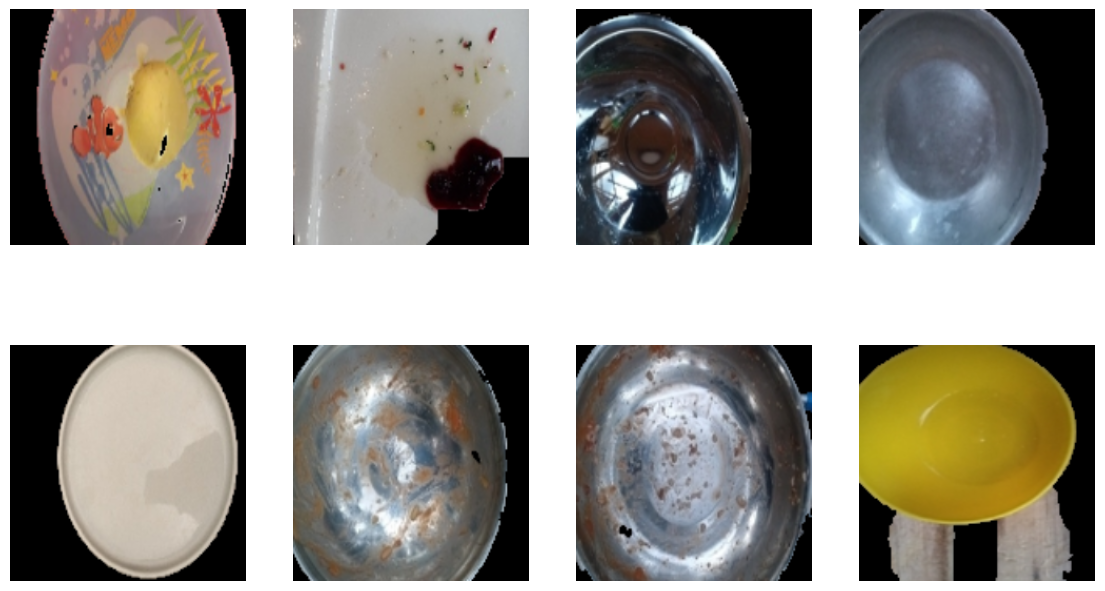

In [27]:
test_transforms = v2.Compose([
    v2.CenterCrop((140, 140)),  # Fixed crop for consistency
    v2.Resize((224, 224)),
    v2.Normalize(mean=train_mean, std=train_std)
])

print('selected transform: ',test_transforms)
test_dataset = PlateDataset(test,transform = test_transforms)
test_dataloader = DataLoader(test_dataset, batch_size= 8,drop_last=False,num_workers=torch.cuda.device_count())

for img in iter(test_dataloader):
    fig,ax = plt.subplots(2,4,figsize = (14,8))
    for i in range(2):
        for j in range(4):
            indx = i*4+j
            #label = lab[indx].item() 
            #print(img[indx].shape) #torch.Size([3, 224, 224])
            img_permute = img[indx].permute(1,2,0)
            #print(img_permute.shape) #torch.Size([224, 224, 3])
            img_numpy = img_permute.numpy()
            image = img_numpy*train_std + train_mean # denormalization
            ax[i][j].imshow(image)
            #ax[i][j].set_title(str(label))
            ax[i][j].axis('off')
    break
            
plt.show()
    

In [28]:
torch.cuda.device_count()

0

In [ ]:
'''
import torch
import torch.optim as optim
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

patience = 2
patient = 0
best_score = float('inf')

def early_stopping(score):
    global patient, best_score  # Use global to keep values across calls

    if score< best_score:
        best_score = score
        patient =0
    else:
        patient += 1 

    return patient > patience
        

def cnn_model_operation(model,x,y,num_epoch,lr,device = None):

    if device is None:  # Use existing device if provided
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    x_train,x_val,y_train,y_val = train_test_split(x,y,test_size = 0.2,random_state = 42)

    # before getting start the training:
    train_dataset = PlateDataset(x_train,y_train,transform = train_random_transform()) #random.choice(train_transforms)
    train_dataloader = DataLoader(train_dataset, batch_size= 8,shuffle = True,drop_last=False,num_workers = torch.cuda.device_count()) # to get the left overs

    val_dataset = PlateDataset(x_val,y_val,transform = val_transforms)
    val_dataloader = DataLoader(val_dataset, batch_size= 8,drop_last=False,num_workers = torch.cuda.device_count())


    #adjust the model as i like
    for param in model.parameters():
        param.requires_grad = False
    #for name, param in model.named_parameters():
    #    print(name,param.requires_grad)
    for param in model.layer4.parameters():
        param.requires_grad = True
    for param in model.fc.parameters():
        param.requires_grad = True

    #add FC layer
    model.fc = nn.Sequential(
    nn.Linear(512,256),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.Dropout(0.5),

    nn.Linear(256,128),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.Dropout(0.5),

    nn.Linear(128,1),
    #nn.Sigmoid() loss function needs to get raw value
    )
    
    num_epoch = num_epoch
    total_train_counter = 0

    criterion = nn.BCEWithLogitsLoss()
    # Define optimizer
    optimizer = optim.Adam(model.parameters(), lr=lr)

    model = model.to(device)#move the model to device after unfreezing/freezing stuff
    
    for epoch in range(num_epoch):
        total_train_loss = 0 
        total_train_acc = 0
        train_counter = 0
        iteration = 0
        model.train() #mode: train
        for image,label in train_dataloader:

            iteration +=1 #count how many iter will be done in this loop 
            num_of_data = label.shape[0]
            train_counter +=num_of_data #accumulate how many data passing through

            #print(label.shape) #torch.Size([8])
            image = image.float()
            label = label.float()
            image = image.to(device)
            label = label.to(device)
    
            optimizer.zero_grad() #clear gradients
            outputs = model(image) 
            outputs=outputs.view(-1)
            #print(outputs.shape) torch.Size([8, 1])
            #print(outputs.view(-1).shape) torch.Size([8])
        
            loss = criterion(outputs,label)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item() #accumulate loss
            #outputs = torch.sigmoid(outputs)
            probs = torch.sigmoid(outputs)
            preds = (probs>0.5).view(-1).float()
            total_train_acc += (preds==label).sum().item()
            #print(train_counter) #8 -- 16 -- 24 -- 28
        

        print(f"Epoch{epoch+1}: train accuracy: {total_train_acc/train_counter:.2f}%, train loss: {total_train_loss/iteration:.2f}%")
        
        total_val_acc = 0
        total_val_loss = 0
        val_counter =0
        
        model.eval()
        with torch.no_grad():
            iteration = 0
            for image,label in val_dataloader:
                iteration +=1
                #print(label.shape) #torch.Size([8])
                num_of_data = image.shape[0]
                val_counter+= num_of_data
                
                image = image.float()
                label = label.float()
                image = image.to(device)
                label = label.to(device)

                output = model(image)
                output = output.view(-1)
                probs = torch.sigmoid(output)
                preds = (probs>0.5).view(-1).float()

                val_loss = criterion(output,label)
                total_val_loss += val_loss.item() #accumulate loss
                total_val_acc += (preds==label).sum().item()
    
        print(f"Epoch{epoch+1}: val accuracy: {total_val_acc/val_counter:.2f}%, val loss: {total_val_loss/iteration:.2f}%")
        print('---------------------------------------------------------------------------')
        if early_stopping(total_val_loss/iteration):
            print("Early stopping triggered!")
            break  # ✅ **Breaks the main training loop**
    return model

'''

## Resnet Model 

In [60]:
import torch
import torch.optim as optim
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(None)
random.seed(None)

patience =5
patient = 0
best_score = float('inf')

def early_stopping(score):
    global patient, best_score  # Use global to keep values across calls

    if score< best_score:
        best_score = score
        patient =0
    else:
        patient += 1 

    return patient > patience
        

def cnn_model_operation(model,x,y,num_epoch,lr,device):
    history = []
    history_train_acc = []
    history_train_loss = []
    history_val_acc = []
    history_val_loss = []


    #if device is None:  # Use existing device if provided
    #    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    x_train,x_val,y_train,y_val = train_test_split(x,y,test_size = 0.2,random_state = 42)

    #adjust the model as i like
    for param in model.parameters():
        param.requires_grad = False
    #for name, param in model.named_parameters():
    #    print(name,param.requires_grad)
    for param in model.layer4.parameters():
        param.requires_grad = True
    for param in model.fc.parameters():
        param.requires_grad = True

    #add FC layer
    model.fc = nn.Sequential(
    nn.Linear(512,256),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.Dropout(0.5),

    nn.Linear(256,128),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.Dropout(0.5),

    nn.Linear(128,1),
    #nn.Sigmoid() loss function needs to get raw value
    )
    
    num_epoch = num_epoch
    total_train_counter = 0

    criterion = nn.BCEWithLogitsLoss()
    # Define optimizer
    optimizer = optim.Adam(model.parameters(), lr=lr)

    model = model.to(device)#move the model to device after unfreezing/freezing stuff
    
    for epoch in range(num_epoch):
        train_transforms = train_random_transform() 
        print('selected transform: ',train_transforms)
        train_dataset = PlateDataset(x_train,y_train,transform = train_transforms) #random.choice(train_transforms)
        train_dataloader = DataLoader(train_dataset, batch_size= 8,shuffle = True,drop_last=False,num_workers = 4,pin_memory=True) # to get the left overs

        
        total_train_loss = 0 
        total_train_acc = 0
        train_counter = 0
        iteration = 0
        model.train() #mode: train
        for image,label in train_dataloader:

            iteration +=1 #count how many iter will be done in this loop 
            num_of_data = label.shape[0]
            train_counter +=num_of_data #accumulate how many data passing through


            #print(label.shape) #torch.Size([8])
            image = image.float()
            label = label.float()
            image = image.to(device, non_blocking=True)
            label = label.to(device, non_blocking=True)
            
            optimizer.zero_grad() #clear gradients
            outputs = model(image) 
            outputs=outputs.view(-1)
            #print(outputs.shape) torch.Size([8, 1])
            #print(outputs.view(-1).shape) torch.Size([8])
        
            loss = criterion(outputs,label)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item() #accumulate loss
            #outputs = torch.sigmoid(outputs)
            probs = torch.sigmoid(outputs)
            preds = (probs>0.5).view(-1).float()
            total_train_acc += (preds==label).sum().item()
            #print(train_counter) #8 -- 16 -- 24 -- 28
        

        print(f"Epoch{epoch+1}: train accuracy: {total_train_acc/train_counter:.2f}%, train loss: {total_train_loss/iteration:.2f}%")
        history_train_acc.append(round((total_train_acc/train_counter),2))
        history_train_loss.append(round((total_train_loss/iteration),2))
        total_val_acc = 0
        total_val_loss = 0
        val_counter =0

        val_transforms = val_random_transform()
        val_dataset = PlateDataset(x_val,y_val,transform = val_transforms)
        val_dataloader = DataLoader(val_dataset, batch_size= 8,drop_last=False,num_workers = 4, pin_memory = True)
        
        model.eval()
        with torch.no_grad():
            iteration = 0
            for image,label in val_dataloader:
                
                iteration +=1
                #print(label.shape) #torch.Size([8])
                num_of_data = image.shape[0]
                val_counter+= num_of_data
                
                image = image.float()
                label = label.float()
                image = image.to(device)
                label = label.to(device)

                output = model(image)
                output = output.view(-1)
                probs = torch.sigmoid(output)
                preds = (probs>0.5).view(-1).float()

                val_loss = criterion(output,label)
                total_val_loss += val_loss.item() #accumulate loss
                total_val_acc += (preds==label).sum().item()
    
        print(f"Epoch{epoch+1}: val accuracy: {total_val_acc/val_counter:.2f}%, val loss: {total_val_loss/iteration:.2f}%")
        history_val_acc.append(round((total_val_acc/val_counter),2))
        history_val_loss.append(round((total_val_loss/iteration),2))
        print('---------------------------------------------------------------------------')
        if early_stopping(total_val_loss/iteration):
            print("Early stopping triggered!")
            break  # ✅ **Breaks the main training loop**
    history= [history_train_acc,history_train_loss,history_val_acc,history_val_loss]
    return model,history

In [61]:
if torch.cuda.is_available():
    print('gpu')
    print('device name:',torch.cuda.get_device_name(0))
else:
    print('cpu')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cpu


In [ ]:
print(device)

In [62]:
# it is with imagenet mean and std value

from torchsummary import summary

model_18 = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=True)
model_18 = model_18.to(device)
#summary(model_18,input_size = (3,224,224),batch_size= 8)

patience = 10
patient = 0
best_score = float('inf')

num_epoch = 100
print(next(model_18.parameters()).device)

myresnet18,history = cnn_model_operation(model_18,x,y,num_epoch,lr=0.0005,device=device)


cpu
selected transform:  Compose(
      CenterCrop(size=(200, 200))
      Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      RandomHorizontalFlip(p=0.3)
      ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


Epoch1: train accuracy: 0.50%, train loss: 0.74%
Epoch1: val accuracy: 0.62%, val loss: 0.68%
---------------------------------------------------------------------------
selected transform:  Compose(
      CenterCrop(size=(140, 140))
      Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      RandomHorizontalFlip(p=0.5)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)
Epoch2: train accuracy: 0.59%, train loss: 0.64%
Epoch2: val accuracy: 0.75%, val loss: 0.64%
---------------------------------------------------------------------------
selected transform:  Compose(
      CenterCrop(size=(200, 200))
      Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      RandomHorizontalFlip(p=0.3)
      ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)
Epoch3: 

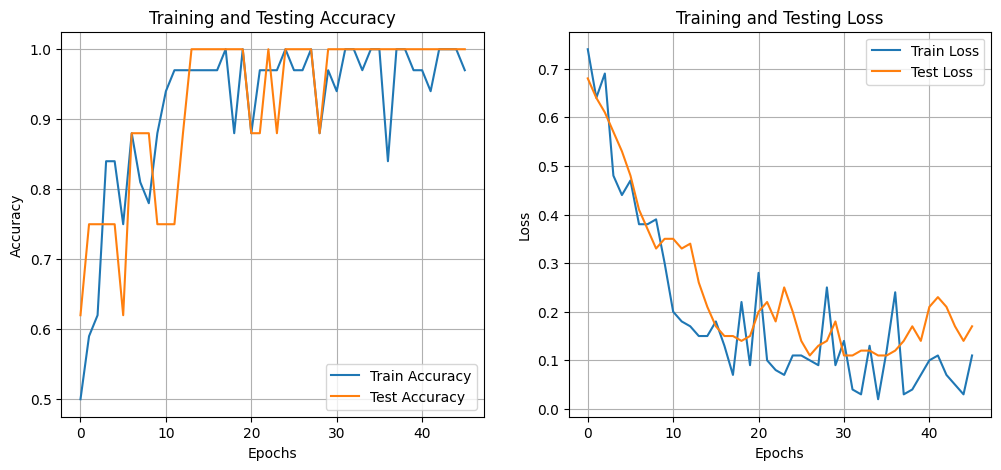

In [63]:
train_acc,train_loss = history[0],history[1]
test_acc,test_loss = history[2],history[3]

# Create figure with two subplots (1 row, 2 columns)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(train_acc, label="Train Accuracy")
ax[0].plot(test_acc, label="Test Accuracy")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Accuracy")
ax[0].set_title("Training and Testing Accuracy")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(train_loss, label="Train Loss")
ax[1].plot(test_loss, label="Test Loss")
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Loss")
ax[1].set_title("Training and Testing Loss")
ax[1].legend()
ax[1].grid(True)

# Show both plots
plt.show()

In [65]:
#test
from tqdm import tqdm

def test_evaluation_export(test,model,excelname):
    test_dataset = PlateDataset(test,transform = test_transforms)
    test_dataloader = DataLoader(test_dataset, batch_size= 8,shuffle = False,drop_last=False)
    
    model.eval()

    total_res = []

    with torch.no_grad():
        for image in tqdm(test_dataloader, desc="Processing Test Data", unit="batch"):
             #print(label.shape) #torch.Size([8])
            image = image.float()
            image = image.to(device)

            output = myresnet18(image)
            output = output.view(-1)
            thresholded_outputs  = (output > 0.5).float()
            a=thresholded_outputs.tolist()
            total_res.extend(a)

    res = []
    for e in total_res:
        if int(e) == 1:
            res.append('cleaned')
        else:
            res.append('dirty')


    ids = []
    for each in test_img_name:
        #print(each)
        name = os.path.basename(each).split('.')[0]
        ids.append(name)
    

    mydict = {'id':ids,
             'label':res}
    mydata = pd.DataFrame(mydict)
    mydata['id'] = mydata['id']
    filename = f"result_{excelname}.csv"
    mydata.to_csv(filename, index=False, float_format='%04d')  # Adds leading zeros when saving

test_evaluation_export(test,myresnet18,'resnet18_5')

Processing Test Data: 100%|██████████| 93/93 [03:09<00:00,  2.04s/batch]


In [ ]:
# it is with imagenet mean and std value

from torchsummary import summary

model_18 = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=True)
model_18.to(device)
#summary(model_18,input_size = (3,224,224),batch_size= 8)

patience = 5
patient = 0
best_score = float('inf')

num_epoch = 30
myresnet18 = cnn_model_operation(model_18,x,y,num_epoch,lr=0.0005,device=device)
test_evaluation_export(test,myresnet18,'resnet18W4O')

In [ ]:
'''from torchsummary import summary

model_18 = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=True)
model_18.to(device)
#summary(model_18,input_size = (3,224,224),batch_size= 8)

patience = 2
patient = 0
best_score = float('inf')

num_epoch = 30
myresnet18 = cnn_model_operation(model_18,x,y,num_epoch,lr=0.0005,device=device)
test_evaluation_export(test,myresnet18,'resnet18_v3')
'''

In [ ]:
#with imagenet mean and std value

model_34 = torch.hub.load('pytorch/vision:v0.10.0', 'resnet34', pretrained=True)
model_34.to(device)
#summary(model_18,input_size = (3,224,224),batch_size= 8)

patience = 2
patient = 0
best_score = float('inf')

num_epoch = 30
myresnet34 = cnn_model_operation(model_34,x,y,num_epoch,lr=0.0005,device=device)
#test_evaluation_export(test,myresnet34,'resnet34')

## Review the outputs:

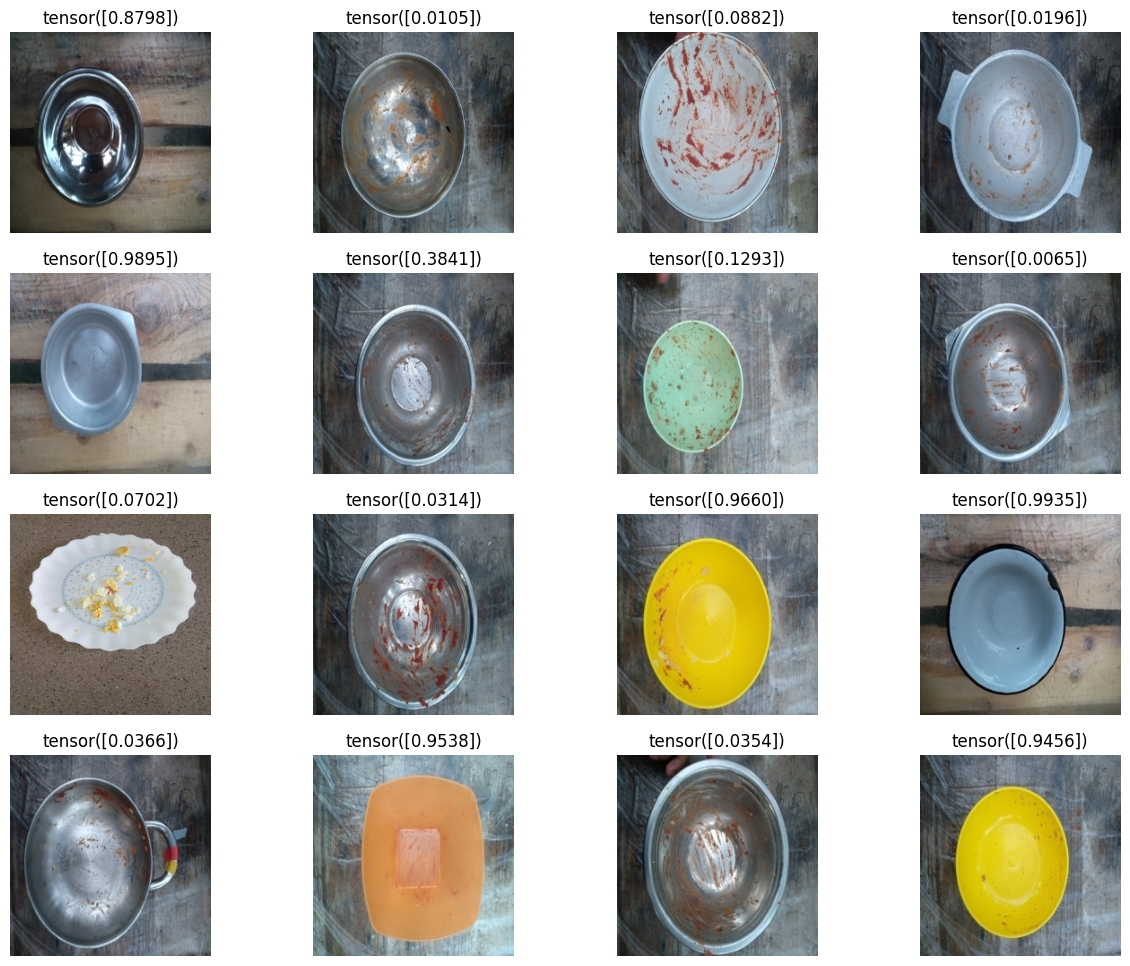

In [66]:
fig, ax = plt.subplots(4,4,figsize = (15,12))
tmodel = myresnet18

test_data = random.sample(test, 16)  # Select 16 random elements

for i in range(4):
    for j in range(4):
        idex = i*4+j
        data = test_data[idex]
        imaj = cv2.imread(data)
        imaj = cv2.resize(imaj,(224,224))
        imaj = cv2.cvtColor(imaj,cv2.COLOR_BGR2RGB)
        torch_imaj = torch.from_numpy(imaj).permute(2,0,1).float()/255
        torch_imaj=torch_imaj.unsqueeze(0)
        torch_imaj=torch_imaj.to(device)
       

        tmodel.eval()
        with torch.no_grad():
            output = tmodel(torch_imaj)
            output = output.view(-1)
            probs = torch.sigmoid(output)
            #print(output)
            ax[i][j].imshow(imaj)
            ax[i][j].set_title(probs)
            ax[i][j].axis('off')

